## Analyse the nuclei and membrane movement

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from typing import Optional
from scipy.signal import savgol_filter
import matplotlib

matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'

## Helper functions for plotting and data organization
def align_tracks_to_min_circularity(df):
    """
    Create `nuc_centroid_aligned`, `mem_front_aligned`, `mem_back_aligned` columns in the cell props dataframe,
    
    Creates aligned spatial and temporal columns by setting the position 
    and frame at minimum nuclear circularity as the 0-point for each cell.
    """
    # Create a copy to avoid SettingWithCopy warnings
    df_aligned = df.copy()
    
    # 1. Find the row index of the minimum circularity for each cell
    min_circ_idx = df_aligned.groupby(['sub', 'cell_idx'])['circularity_nuc'].idxmin()
    
    # 2. Extract BOTH 'pos_on_track' and 'frame' at those specific indices
    ref_df = df_aligned.loc[min_circ_idx, ['sub', 'cell_idx', 'pos_on_track', 'frame']]
    ref_df = ref_df.rename(columns={'pos_on_track': 'x0', 'frame': 'frame0'})
    
    # 3. Merge these reference values back to all rows of the corresponding cell
    df_aligned = df_aligned.merge(ref_df, on=['sub', 'cell_idx'], how='left')
    
    # 4. Perform the offsets for the spatial columns
    df_aligned['nuc_centroid_aligned'] = df_aligned['pos_on_track'] - df_aligned['x0']
    df_aligned['mem_front_aligned'] = df_aligned['mem_front'] - df_aligned['x0']
    df_aligned['mem_back_aligned'] = df_aligned['mem_back'] - df_aligned['x0']
    
    # 5. Perform the offset for the temporal column (Time = 0 at min circularity)
    df_aligned['aligned_frame_idx'] = df_aligned['frame'] - df_aligned['frame0']
    
    # 6. Drop the temporary reference columns to keep the dataframe clean
    df_aligned = df_aligned.drop(columns=['x0', 'frame0'])
    
    return df_aligned

def plot_var_dynamics(df, var='pos_on_track_aligned', duration=10, ax = None, color='#1f77b4', error = 'std'):
    """
    Plots the mean and standard deviation of a variable across all cells, 
    centered around frame_aligned = 0.
    
    Parameters:
    -----------
    df : pandas DataFrame
        The dataframe containing your cell tracks (must have 'frame_aligned' and the 'var' column).
    var : str
        The name of the column you want to plot on the Y-axis.
    duration : int
        The number of frames to show before and after 0 (plots from -duration to +duration).
    error: 'sem' or 'std'
    """
    
    # 1. Filter the dataframe to only include the requested time window
    df_window = df[(df['aligned_frame_idx'] >= -duration) & (df['aligned_frame_idx'] <= duration)]
    
    # 2. Group by the aligned frame and calculate mean and standard deviation
    grouped = df_window.groupby('aligned_frame_idx')[var]
    mean_vals = grouped.mean()
    if error == 'std':
        err_vals = grouped.std()# Standard error of the mean
    elif error == 'sem':
        err_vals = grouped.std()/grouped.count()**0.5
    
    # Ensure our X-axis values are the index (which is frame_aligned)
    frames = mean_vals.index
    
    # 3. Create the plot
    if ax is None:
        ax = plt.gca()
    
    # Plot the mean line
    ax.plot(frames, mean_vals, color=color, linewidth=2.5, label=f'{var}')
    
    # Plot the standard deviation ribbon
    ax.fill_between(frames, 
                     mean_vals - err_vals, 
                     mean_vals + err_vals, 
                     color=color, alpha=0.2)
    
    # 4. Add a vertical line to mark the biological event (frame 0)
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.8)
    
    # 5. Formatting for readability
    
    ax.set_xlabel('Aligned Frame (0 = Minimum Circularity)')
    ax.set_ylabel(var)
    
    # Force the X-axis limits to match the requested duration perfectly
    ax.set_xlim(-duration, duration)
    
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
    plt.tight_layout()

def plot_measurement_traces(
    df: pd.DataFrame, 
    var: str = 'speed_nuc', 
    duration: int = 50, 
    ax: Optional[plt.Axes] = None, 
    **kwargs
) -> plt.Axes:
    """
    Plots individual cell traces aligned to a specific event (e.g., min circularity).

    Args:
        df: The input dataframe containing 'sub', 'cell_idx', and 'aligned_frame_idx'.
        var: The column name to plot on the y-axis.
        duration: The time window to display (from -duration to +duration).
        ax: A matplotlib axes object. If None, a new figure is created.
        **kwargs: Standard matplotlib line properties (color, alpha, lw, etc.) 
                  passed to ax.plot().

    Returns:
        The matplotlib axes object containing the plots.
    """
    # 1. Input Validation
    required_cols = ['sub', 'cell_idx', 'aligned_frame_idx', var]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Required column '{col}' not found in DataFrame.")

    # 2. Filter data by the duration window immediately for performance
    plot_df = df[(df['aligned_frame_idx'] >= -duration) & 
                (df['aligned_frame_idx'] <= duration)].copy()

    if plot_df.empty:
        print(f"Warning: No data found within the window [-{duration}, {duration}]")
        return ax

    # 3. Setup plotting environment
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    # 4. Set default styling if not provided in kwargs
    # We use a low alpha by default so many overlapping traces don't become a blob
    kwargs.setdefault('alpha', 0.3)
    kwargs.setdefault('color', 'gray')

    # 5. Group by Subject and Cell and plot traces
    # Grouping by both ensures unique traces even if cell_idx repeats across subjects
    for (sub_id, cell_id), trace in plot_df.groupby(['sub', 'cell_idx']):
        # Sort by time to ensure lines don't zig-zag
        trace = trace.sort_values('aligned_frame_idx')
        ax.plot(trace['aligned_frame_idx'], trace[var], **kwargs)

    # 6. Formatting
    ax.axvline(0, color='black', linestyle='--', alpha=0.5, label='Alignment Point')
    ax.set_xlabel('Aligned Frame Index')
    ax.set_ylabel(var.replace('_', ' ').title())
    ax.set_xlim(-duration, duration)
    ax.grid(True, linestyle=':', alpha=0.6)

    return ax



def add_robust_1d_speed(df, target_col, window_size=11, polyorder=2, absolute=True):
    """
    Calculates the 1D speed (derivative) of a specific column.
    
    Args:
        df: Dataframe containing 'sub', 'cell_idx', and 'frame'.
        target_col: The column to differentiate (e.g., 'pos_on_track').
        window_size: Filter window length (must be odd).
        polyorder: Polynomial order for the fit.
        absolute: If True, returns speed (magnitude). If False, returns velocity (signed).
    """
    # Create the output column name
    new_col = f"speed_{target_col}"
    df[new_col] = np.nan # Initialize with NaNs
    
    # Group by cell to avoid calculating speed across different tracks
    for (sub_id, cell_id), group in df.groupby(['sub', 'cell_idx']):
        if len(group) < 3:
            continue
            
        # Ensure data is chronological
        group = group.sort_values('frame')
        
        # Adjust window size if the track is shorter than the requested window
        w = window_size
        if len(group) <= w:
            w = len(group) if len(group) % 2 != 0 else len(group) - 1
            
        if w < 3:
            continue

        # Calculate the 1st derivative (deriv=1)
        # Note: This assumes delta_t = 1 frame. 
        # If you want real-time units (um/min), divide by your frame interval.
        deriv = savgol_filter(group[target_col], window_length=w, polyorder=polyorder, deriv=1)
        
        if absolute:
            deriv = np.abs(deriv)
            
        df.loc[group.index, new_col] = deriv
        
    return df

def calculate_corr(df, col1, col2, duration=30):
    """
    Calculates the Pearson correlation between two variables for each cell
    within a window centered at the alignment point (aligned_frame_idx = 0).

    Args:
        df: DataFrame containing 'sub', 'cell_idx', 'aligned_frame_idx', col1, col2.
        col1, col2: The names of the two columns to correlate.
        duration: The window size (from -duration to +duration).

    Returns:
        A DataFrame with columns: ['sub', 'cell_idx', 'cross_corr']
    """
    # 1. Filter the window first for performance
    df_window = df[(df['aligned_frame_idx'] >= -duration) & 
                   (df['aligned_frame_idx'] <= duration)].copy()
    
    # 2. Group by subject and cell
    # We use a custom lambda to calculate correlation for each group
    # .corr() returns a matrix; we take the top-right value [col1, col2]
    def get_group_corr(group):
        if len(group) < 3: # Need at least a few points for a meaningful correlation
            return np.nan
        return group[col1].corr(group[col2])

    # Apply the correlation calculation
    results = df_window.groupby(['sub', 'cell_idx']).apply(get_group_corr)
    
    # 3. Clean up the resulting Series into the requested DataFrame format
    results_df = results.reset_index()
    results_df.columns = ['sub', 'cell_idx', 'cross_corr']
    
    return results_df

In [2]:
csv_path = r'C:\Users\kou12\Documents\github\ScarpaLab\cell_migration_analysis\03-extracted_params\combined_cell_profiles.csv'
df = pd.read_csv(csv_path)
aligned_df = align_tracks_to_min_circularity(df)

aligned_df =add_robust_1d_speed(aligned_df, 'nuc_centroid_aligned', window_size=11, polyorder=2, absolute=False)
aligned_df = add_robust_1d_speed(aligned_df, 'mem_front_aligned', window_size=11, polyorder=2, absolute=False)
aligned_df = add_robust_1d_speed(aligned_df, 'mem_back_aligned', window_size=11, polyorder=2, absolute=False)

In [3]:
# fig, ax = plt.subplots(figsize=(5,5))
# plot_measurement_traces(aligned_df_, var = 'speed_mem_back_aligned', color='orange', alpha=0.3, ax=ax)
# plot_measurement_traces(aligned_df_, var = 'speed_nuc_centroid_aligned', color='b', alpha=0.3, ax=ax)
# plot_measurement_traces(aligned_df_, var = 'speed_mem_front_aligned', color='g', alpha=0.3, ax=ax)
# # Inverse the y-axis to match the direction of cell movement
# plt.gca().invert_yaxis()

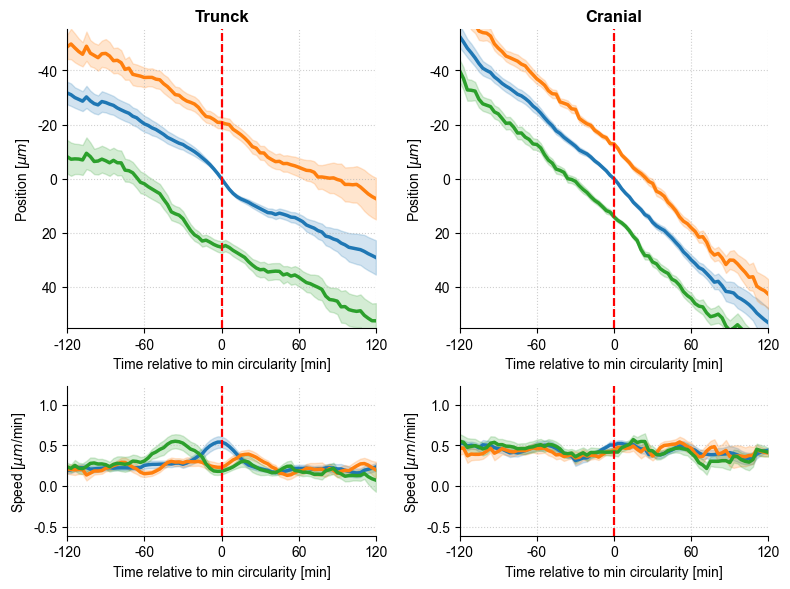

In [3]:
fig, axes = plt.subplots(2,2,figsize=(8,6), height_ratios=[2,1])

pxl_size = 0.368 # um/pxl
frame_rate = 3 # min/frame

aligned_df_trunck = aligned_df[(aligned_df['sub'].isin([1,2,3,4,5,7,8,31,32,33,34]))]
aligned_df_cranial = aligned_df[(aligned_df['sub'].isin([23,24,25,26]))]

error_plot = 'sem'

for i, (df, body_part) in enumerate(zip([aligned_df_trunck, aligned_df_cranial], ['Trunck', 'Cranial'])):
    
    plot_var_dynamics(df, var='nuc_centroid_aligned', duration=40, ax=axes[0,i], color='#1f77b4', error=error_plot)
    plot_var_dynamics(df, var='mem_back_aligned', duration=40, ax=axes[0,i], color='#ff7f0e', error=error_plot)
    plot_var_dynamics(df, var='mem_front_aligned', duration=40, ax=axes[0,i], color='#2ca02c', error=error_plot)
    axes[0,i].set_title(f'{body_part}', fontweight='bold')
    axes[0,i].legend().set_visible(False)
    axes[0,i].set_ylim(150,-150)
    axes[0,i].set_xticks(np.array([-40, -20, 0, 20, 40]))
    axes[0,i].set_xticklabels(np.array([-40, -20, 0, 20, 40])*frame_rate)
    axes[0,i].set_yticks(np.array([-40, -20, 0, 20, 40])/pxl_size)
    axes[0,i].set_yticklabels(np.array([-40, -20, 0, 20, 40]))
    axes[0,i].set_ylabel(r'Position [$\mu m$]')
    axes[0,i].set_xlabel('Time relative to min circularity [min]')

    plot_var_dynamics(df, var='speed_nuc_centroid_aligned', duration=40, ax=axes[1,i], color='#1f77b4', error=error_plot)
    plot_var_dynamics(df, var='speed_mem_back_aligned', duration=40, ax=axes[1,i], color='#ff7f0e', error=error_plot)
    plot_var_dynamics(df, var='speed_mem_front_aligned', duration=40, ax=axes[1,i], color='#2ca02c', error=error_plot)
    axes[1,i].legend().set_visible(False)
    
    axes[1,i].set_xticks(np.array([-40, -20, 0, 20, 40]))
    axes[1,i].set_xticklabels(np.array([-40, -20, 0, 20, 40])*frame_rate)
    axes[1,i].set_yticks(np.arange(-1, 2, 0.5)/(pxl_size/frame_rate))
    axes[1,i].set_yticklabels(np.arange(-1, 2, 0.5))
    axes[1,i].set_ylim(-5,10)
    axes[1,i].set_ylabel(r'Speed [$\mu m$/min]')
    axes[1,i].set_xlabel('Time relative to min circularity [min]')
sns.despine()
plt.tight_layout()
plt.savefig(f'C:\\Users\\kou12\\Documents\\github\\ScarpaLab\\cell_migration_analysis\\05-plots\\aligned_dynamics_{error_plot}.svg')

In [4]:
aligned_df.to_csv(r'C:\Users\kou12\Documents\github\ScarpaLab\cell_migration_analysis\03-extracted_params\aligned_cell_profiles.csv', index=False)

In [11]:
aligned_df.columns

Index(['cell_idx', 'area_nuc', 'centroid-y_nuc', 'centroid-x_nuc',
       'solidity_nuc', 'perimeter_nuc', 'eccentricity_nuc',
       'axis_major_length_nuc', 'axis_minor_length_nuc', 'frame',
       'circularity_nuc', 'aspect_ratio_nuc', 'speed_nuc', 'area_mem',
       'centroid-y_mem', 'centroid-x_mem', 'solidity_mem', 'perimeter_mem',
       'eccentricity_mem', 'axis_major_length_mem', 'axis_minor_length_mem',
       'circularity_mem', 'aspect_ratio_mem', 'speed_mem', 'pos_on_track',
       'mem_front', 'mem_back', 'sub', 'nuc_centroid_aligned',
       'mem_front_aligned', 'mem_back_aligned', 'aligned_frame_idx',
       'speed_nuc_centroid_aligned', 'speed_mem_front_aligned',
       'speed_mem_back_aligned'],
      dtype='object')

In [14]:
import pandas as pd
import numpy as np

# 'speed_mem_back_aligned', 'speed_mem_front_aligned', 'speed_nuc_centroid_aligned'

corr_df = calculate_corr(aligned_df, 'speed_nuc_centroid_aligned', 'speed_mem_back_aligned', duration=20)
metadata = pd.read_csv(r'C:\Users\kou12\Documents\github\ScarpaLab\cell_migration_analysis\03-extracted_params\metadata.csv')
corr_df = corr_df.merge(metadata, on='sub', how='left')
corr_df.to_csv(r'C:\Users\kou12\Documents\github\ScarpaLab\cell_migration_analysis\03-extracted_params\cross_correlation_mem_back.csv', index=False)

C:\Users\kou12\AppData\Local\Temp\ipykernel_42632\3317420660.py:235: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = df_window.groupby(['sub', 'cell_idx']).apply(get_group_corr)


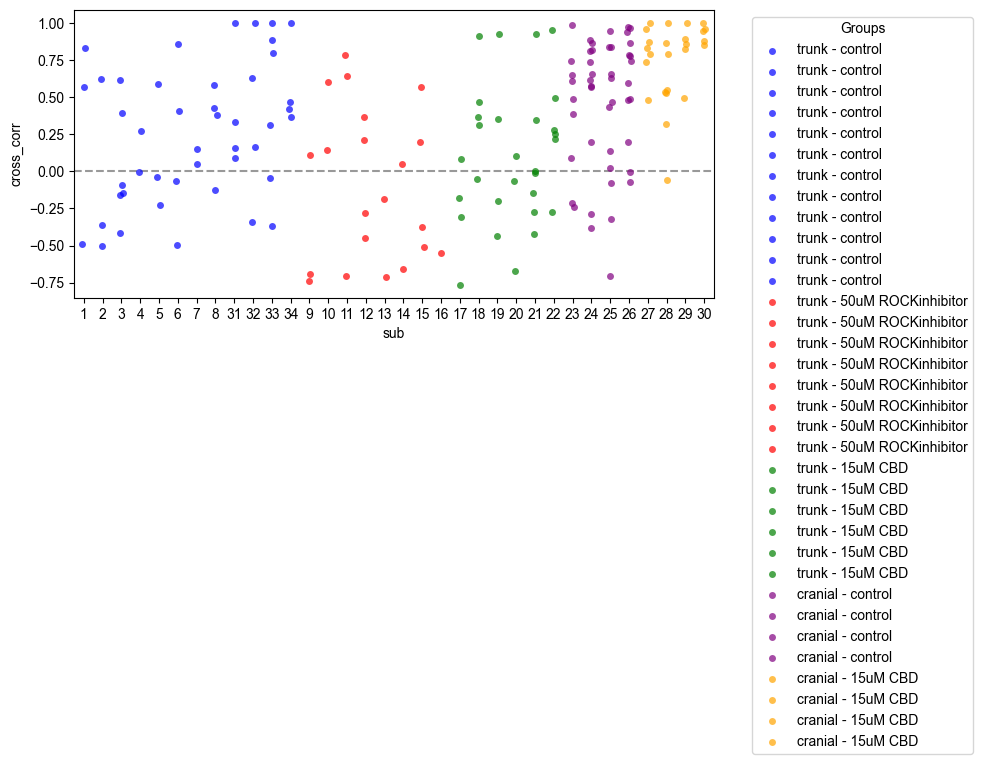

In [15]:
def plot_stripplot(df, bodyPart='trunk', treatment='control', ax=None, color=None):
    df_ = df[
        (df['treatment'] == treatment) &
        (df['bodyPart'] == bodyPart)
    ].reset_index(drop=True)
    
    # Create a unique label for this specific group
    group_label = f"{bodyPart} - {treatment}"
    
    sns.stripplot(
        data=df_, 
        y='cross_corr', 
        x='sub', 
        label=group_label, 
        color=color, 
        ax=ax,
        alpha=0.7
    )

# When plotting, pass different colors and call legend at the end
fig, ax = plt.subplots(figsize=(10, 6))

plot_stripplot(corr_df, 'trunk', 'control', ax=ax, color='blue')
plot_stripplot(corr_df, 'trunk', '50uM ROCKinhibitor', ax=ax, color='red')
plot_stripplot(corr_df, 'trunk', '15uM CBD', ax=ax, color='green')
plot_stripplot(corr_df, 'cranial', 'control', ax=ax, color='purple')
plot_stripplot(corr_df, 'cranial', '15uM CBD', ax=ax, color='orange')

plt.axhline(0, color='gray', linestyle='--', alpha=0.8)

# This collects all 'label' arguments from the previous calls
plt.legend(title="Groups", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [8]:
metadata.treatment.unique()

array(['control', '50uM ROCKinhibitor', '15uM CBD'], dtype=object)

In [9]:
# Perform Ranksum test to compare the two groups
from scipy.stats import ranksums

# Extract the correlation values for each group
trunck_corrs = corr_df_trunck['cross_corr'].dropna()
cranial_corrs = corr_df_cranial['cross_corr'].dropna()
# Perform the Ranksum test
statistic, p_value = ranksums(trunck_corrs, cranial_corrs)
print(f"Ranksum statistic: {statistic}, p-value: {p_value}")

NameError: name 'corr_df_trunck' is not defined